# Notebook No-DRaMA - Viewing Geometry

author: Wietske Brouwer 


The theory behind the viewing geometry can be found in this paper: https://ieeexplore.ieee.org/abstract/document/10273425/metrics#metrics


## Data 
We have already computed the viewing geometry to save time. 
You can download the viewing geometry for Krakow and Svalbard here: https://surfdrive.surf.nl/s/6icc5XyRkngzZHk




In [1]:
%matplotlib inline

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import pandas as pd

from drama.performance.sar import SARModeFromCfg
from drama.io import cfg
from drama.mission.timeline import LatLonTimeline

import drama.mission.timeline.no_drama as nd
import pickle
import os


import matplotlib
from mpl_toolkits.mplot3d import Axes3D



## Viewing geometry

The estimated relative displacements resulting from InSAR parameter estimation are projections of the 3-D displacement vector onto the line of sight (LoS) direction defined at the position of the target.

The LoS direction depends on the viewing geometry toward the satellite. Therefore, the LoS direction is described using two angles:
- The azimuth of the zero Dopler plane ZDP at the Earth’s surface, $\alpha_d$
- The incidence angle $\theta$

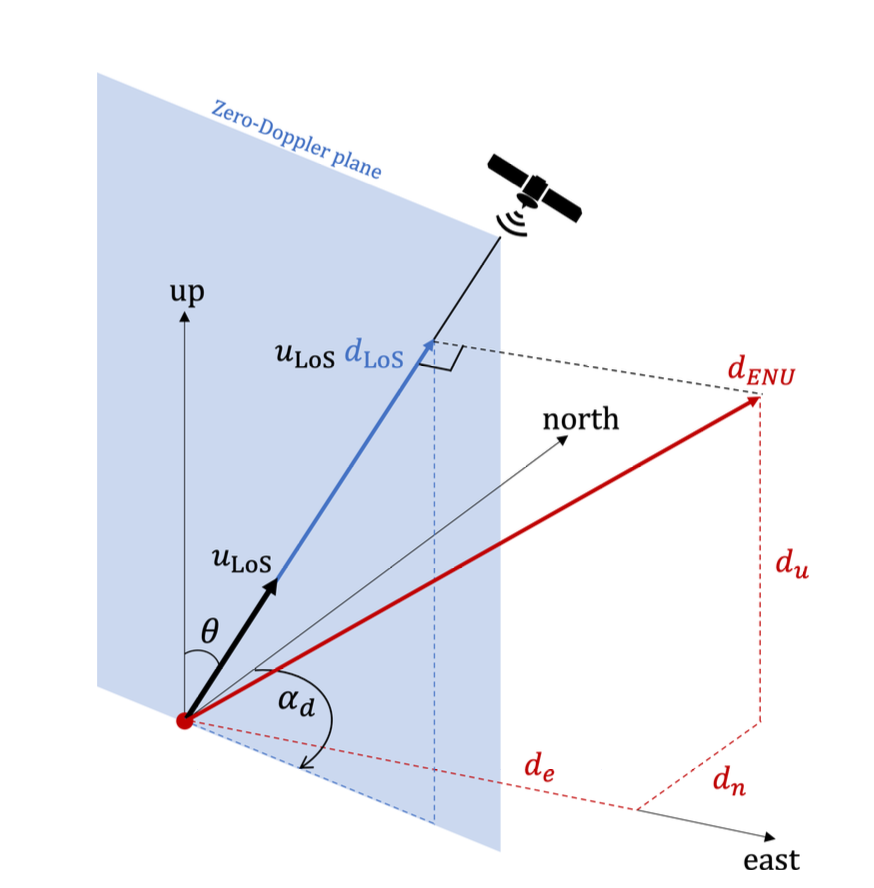

**The azimuth of the ZDP**
The satellite has a time-varying orbital heading $\alpha_h$ which is teh anle between the velocity vector of the satellite and the geometrical north.The LoS vector lies in the ZDP.
The heading, $\alpha_h$, and the orientation of the ZDP—in a satellite-centered coordinate frame—are different from the direction of the velocity vector and the azimuth of the ZDP, $\alpha_d$ , in a target-centered coordinate frame on the Earth’s surface.

This effect is caused by the side-looking geometry of the SAR and the nonparallel nature (convergence) of the Earth’s meridians. In addition, the azimuth of the ZDP is range-dependent. These effects are relevant when computing the viewing geometry.

**The Incidence angle**
The incidence angle, $\theta$, refers to the nominal (ellipsoidal) incidence angle, the angle between the normal vector on the local ellipsoid, at the position of the target, and the line of sight toward the satellite in the ZDP. The incidence angle differs from the satellite look angle θl, which is the angle between the LoS direction


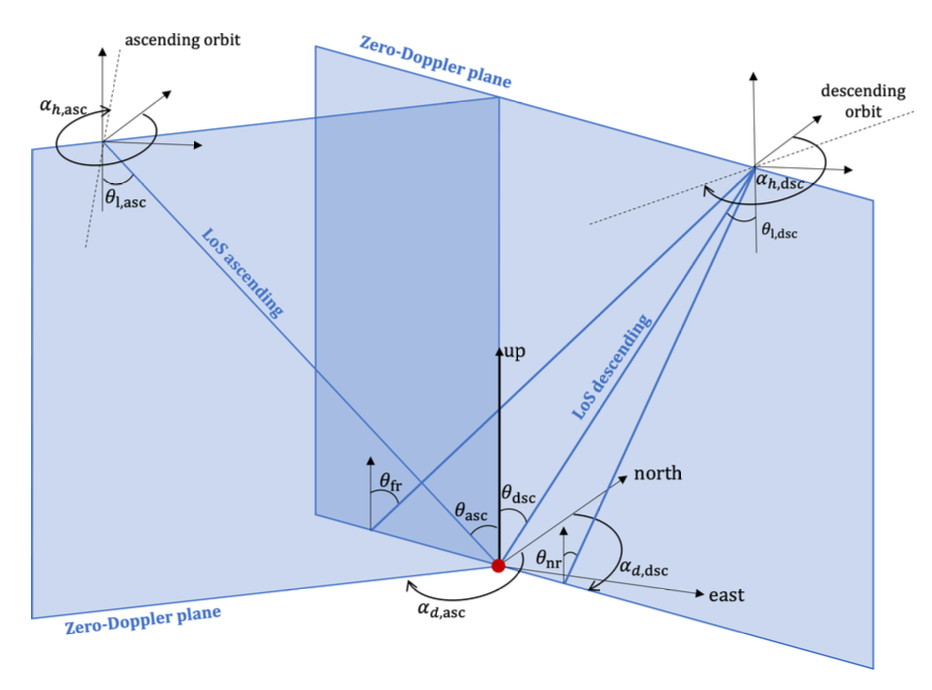

## <font color='blue'>Example 1:</font> Estimate the viewing geometry for one particular location on Earth


### Example 1: Estimate viewing geometry for one particular location on Earth
For a location on earth, defined by a latitudinal and longitudinal coordinate, we can compute the viewing geometry of the available acquisitions. We have already computed this for two locations on earth:

- **Krakow** which has the (lat/lon) location: 50.049683 , 19.944544
- **Svalbard** which has the (lat/lon) location: 79.004559, 17. 666017




The pickled geometry has the following information:
1. nr_asc_obs: list of the number of available ascending observations for particular location
2. nr_desc_obs: list of the number of available descending observations for particular location
3. asc_inc: list of the incidence angles of the ascending acquisitions per location 
4. desc_inc: list of the incidence angles of the descending acquisitions per location  
5. asc_alpha: list of the azimuth of the ZDP of the ascending acquisitions per location  
6. desc_alpha: list of the azimuth of the ZDP of the descending acquisitions per location




In [2]:
# Load the results for Krakow
#set up the path to the data file
path = '/Users/isabelslingerland/insar_and_geodesy/book/day_one/basics_of_sar_interferometry/notebooks/'
data = os.path.join(path, 'viewing_geometry_krakow.pkl')
#join path with the current working directory

with open(data, 'rb') as f:
    results = pickle.load(f)

nr_asc_obs_krakow = results['nr_asc_obs']
nr_desc_obs_krakow = results['nr_desc_obs']
asc_inc_krakow = results['asc_inc']
desc_inc_krakow = results['desc_inc']
asc_alpha_krakow = results['asc_alpha']
desc_alpha_krakow = results['desc_alpha']

print("Results for Krakow loaded!")


data = os.path.join(path, 'viewing_geometry_svalbard.pkl')

with open(data, 'rb') as f:
    results = pickle.load(f)

nr_asc_obs_svalbard = results['nr_asc_obs']
nr_desc_obs_svalbard = results['nr_desc_obs']
asc_inc_svalbard = results['asc_inc']
desc_inc_svalbard = results['desc_inc']
asc_alpha_svalbard = results['asc_alpha']
desc_alpha_svalbard = results['desc_alpha'] 

print("Results for Svalbard loaded!")

Results for Krakow loaded!
Results for Svalbard loaded!


Putting it in a dataframe just to visualise and compare

In [3]:
def geometry_to_dict(lat, lon, nr_asc, asc_inc, asc_alpha, nr_desc, desc_inc, desc_alpha):
    d = {'lat': lat, 'lon': lon, 'nr_asc_obs': nr_asc, 'nr_desc_obs': nr_desc}
    
    for k in range(3):
        d[f'asc_inc{k+1}']    = np.rad2deg(asc_inc[0][k])    if k < np.size(asc_inc[0])    else np.nan
        d[f'asc_alpha{k+1}']  = np.rad2deg(asc_alpha[0][k])  if k < np.size(asc_alpha[0])  else np.nan
        d[f'desc_inc{k+1}']   = np.rad2deg(desc_inc[0][k])   if k < np.size(desc_inc[0])   else np.nan
        d[f'desc_alpha{k+1}'] = np.rad2deg(desc_alpha[0][k]) if k < np.size(desc_alpha[0]) else np.nan
    return d

rows = {
    'Krakow':   geometry_to_dict(50.049683, 19.944544,
                                 nr_asc_obs_krakow,   asc_inc_krakow,   asc_alpha_krakow,
                                 nr_desc_obs_krakow,  desc_inc_krakow,  desc_alpha_krakow),
    'Svalbard': geometry_to_dict(79.004559, 17.666017,
                                 nr_asc_obs_svalbard, asc_inc_svalbard, asc_alpha_svalbard,
                                 nr_desc_obs_svalbard, desc_inc_svalbard, desc_alpha_svalbard),
}

df = pd.DataFrame.from_dict(rows, orient='index')
df.index.name = 'Location'
df

,lat,lon,nr_asc_obs,nr_desc_obs,asc_inc1,asc_alpha1,desc_inc1,desc_alpha1,asc_inc2,asc_alpha2,desc_inc2,desc_alpha2,asc_inc3,asc_alpha3,desc_inc3,desc_alpha3
Location,,,,,,,,,,,,,,,,
Krakow,50.049683,19.944544,2,1,36.075718,259.401848,38.124704,100.210118,44.466359,260.985411,NaN,NaN,NaN,NaN,NaN,NaN
Svalbard,79.004559,17.666017,6,7,32.369418,243.927313,38.581357,111.170138,44.448785,253.877078,43.286366,107.143686,39.905911,249.89408,30.900582,117.128419


__What are the differences between Krakow and Svalbard?__

## <font color='blue'>Example 2:</font> Estimate and visualize the orientation of the null line for a particular location

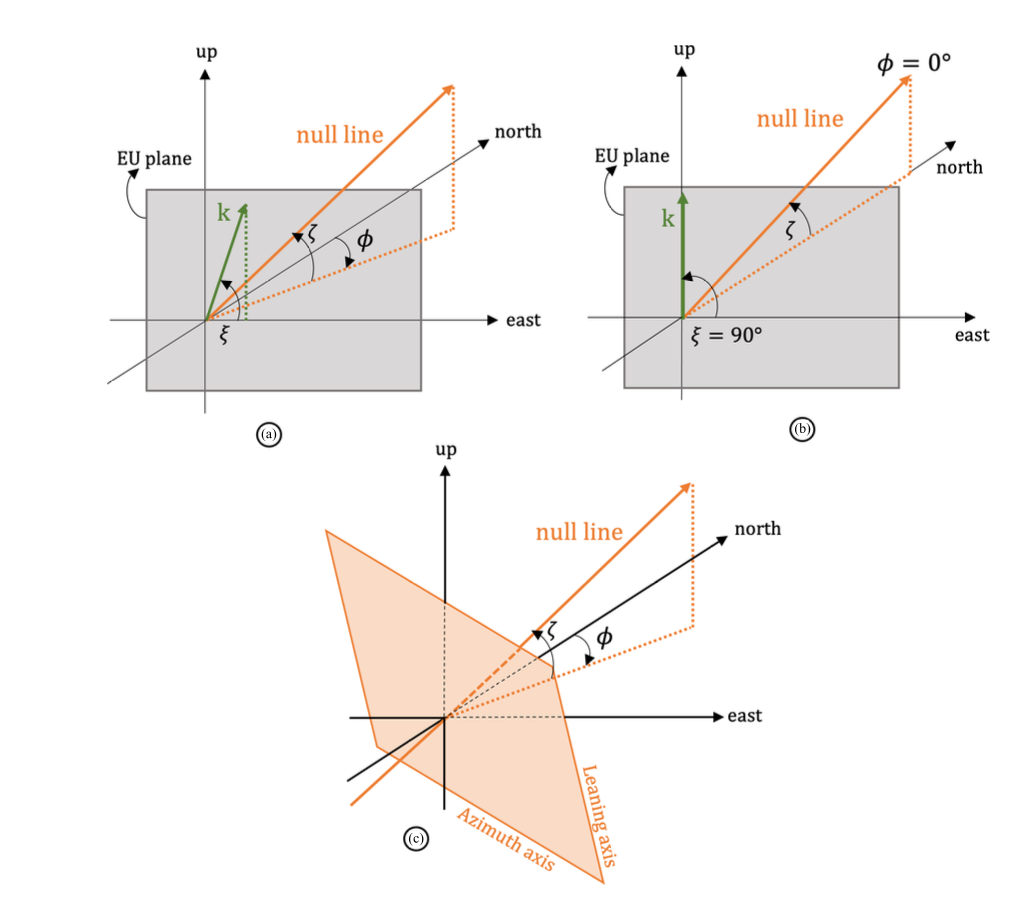



For each of these locations on earth we can estimate the orientation of the null line with `phi_zeta` and corresponding viewing geometry.
In the example below we compute the orientation of the null line for the location specified.

Note that when there are multiple ascending and/or descending acquisitions available, we can compute the multiple null lines by combining different ascending and descending acquisitions. 

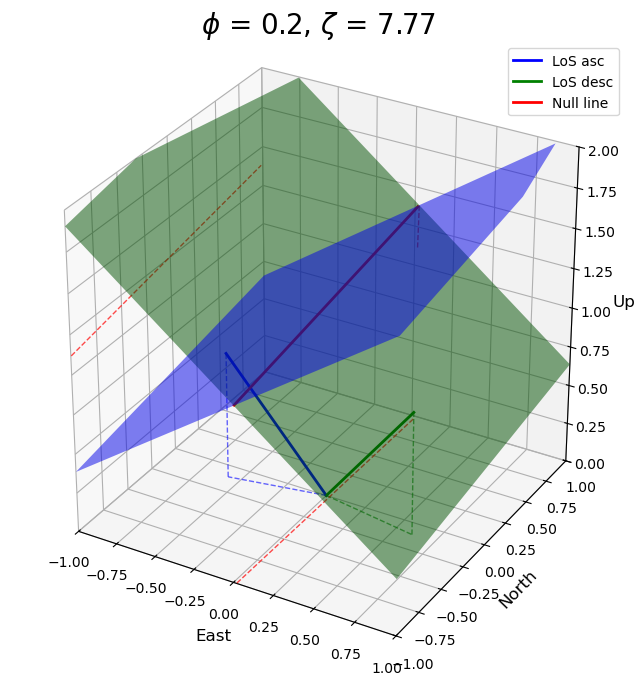

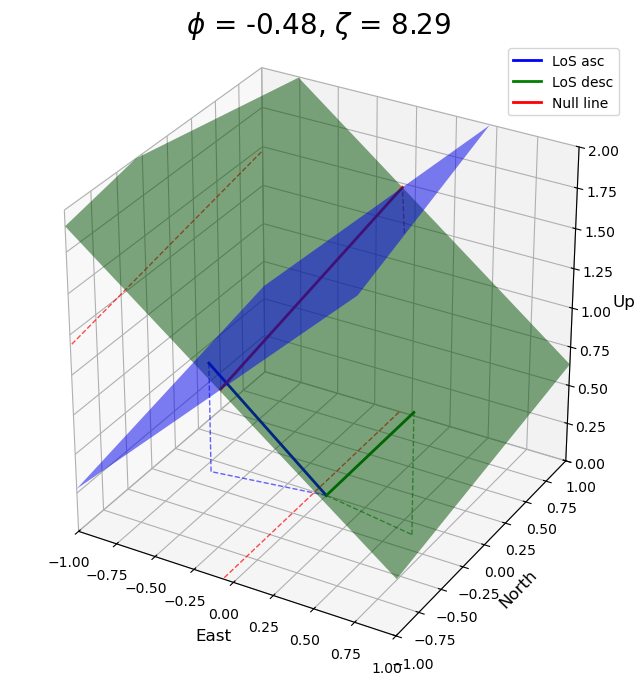

In [4]:


# Safe gca patch - guarded so it only applies once
if not hasattr(matplotlib.figure.Figure, '_original_gca'):
    matplotlib.figure.Figure._original_gca = matplotlib.figure.Figure.gca

    def patched_gca(self, **kwargs):
        if 'projection' in kwargs:
            return self.add_subplot(111, **kwargs)
        return self.axes[-1] if self.axes else self.add_subplot(111)

    matplotlib.figure.Figure.gca = patched_gca


# Extract FIRST, then initialize with correct sizes
inc_a = asc_inc_krakow[0]
inc_d = desc_inc_krakow[0]
alpha_asc = asc_alpha_krakow[0]
alpha_desc = desc_alpha_krakow[0]

phi = np.zeros((np.size(inc_a), np.size(inc_d)))
zeta = np.zeros((np.size(inc_a), np.size(inc_d)))

for i in range(np.size(inc_a)):
    for j in range(np.size(inc_d)):
        inc = np.array([inc_a[i], inc_d[j]])
        alpha_d = np.array([alpha_asc[i], alpha_desc[j]])
        
        unit_los_enu, zeta[i,j], phi[i,j], xi = nd.null_space_2sat(inc, alpha_d, 1, 'LoS asc', 'LoS desc')

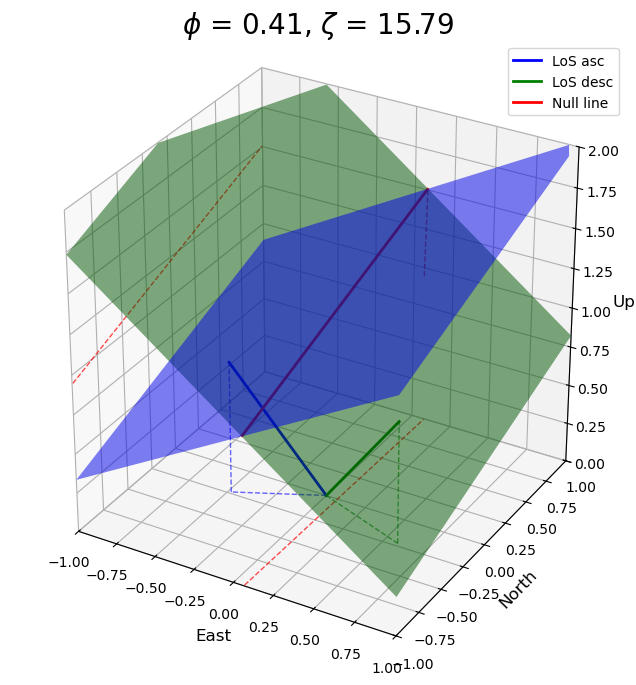

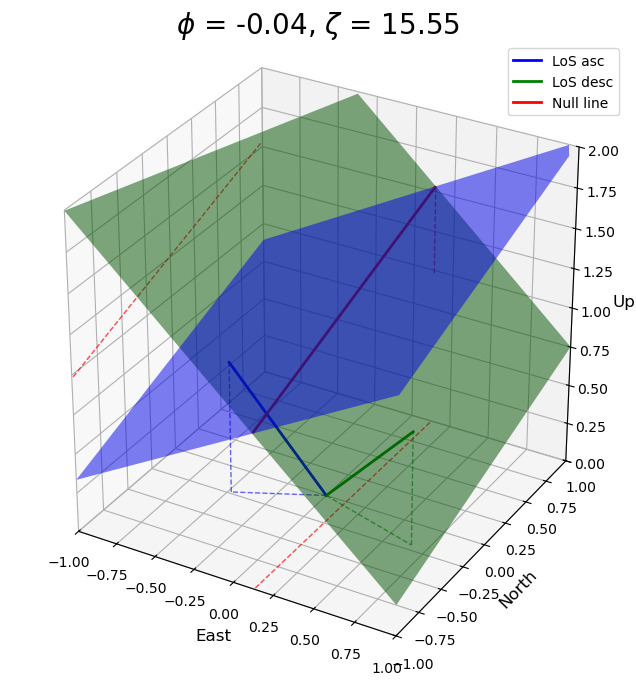

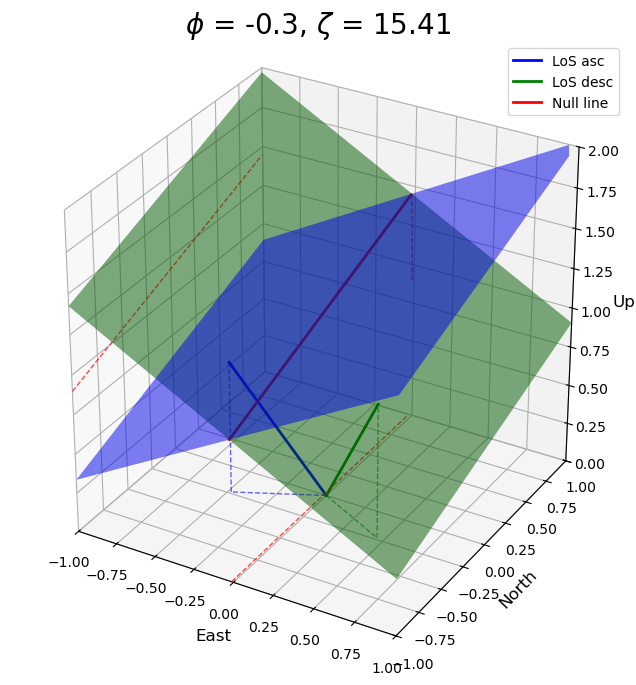

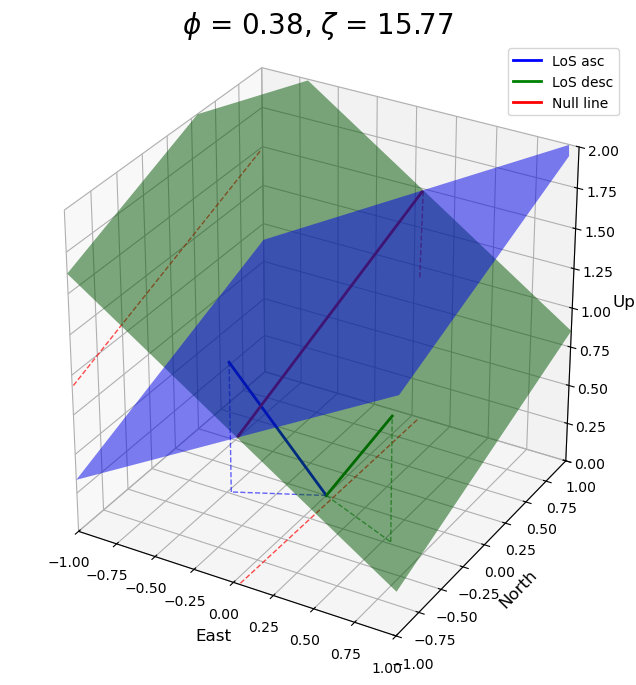

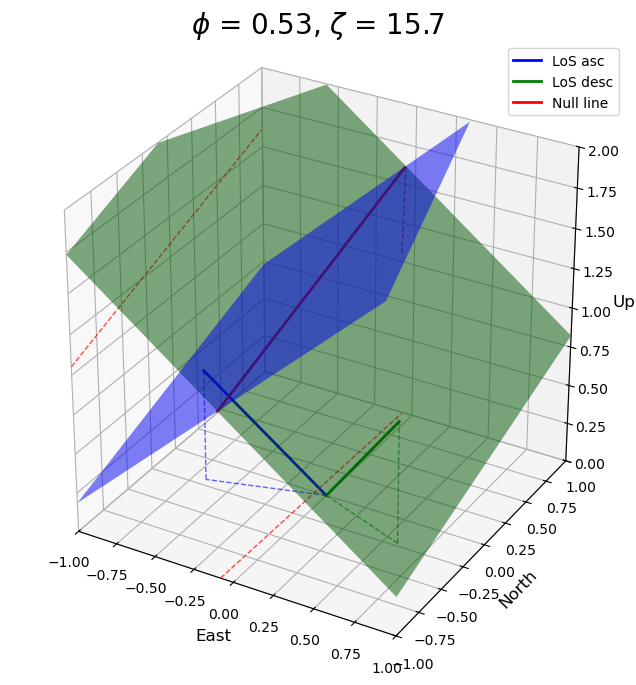

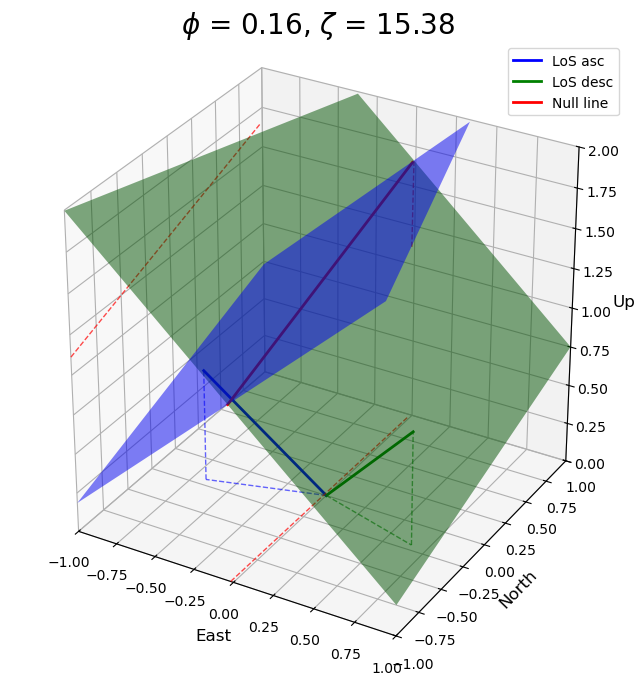

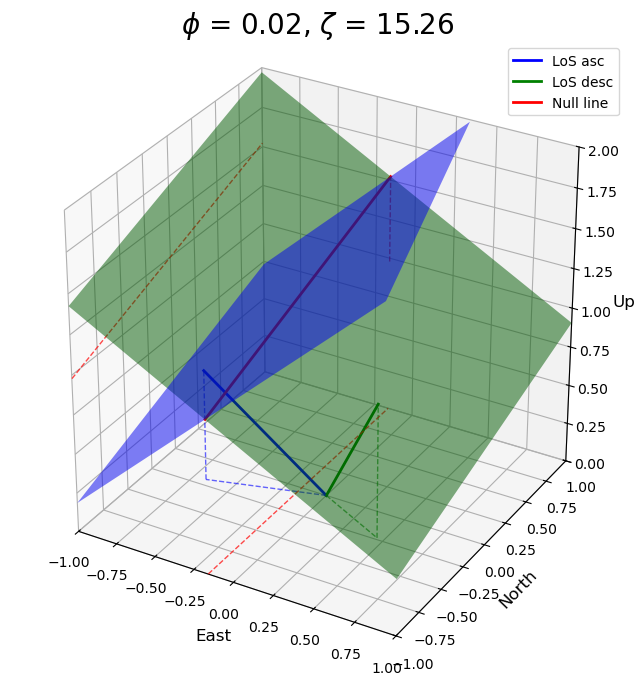

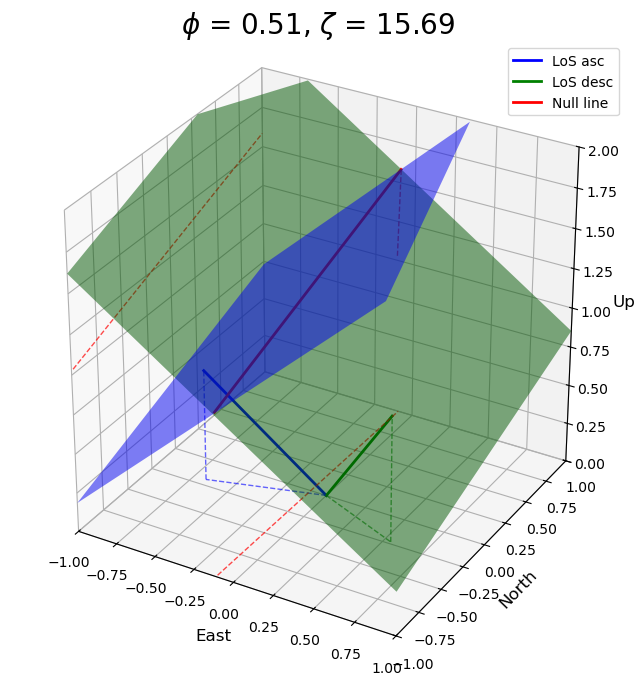

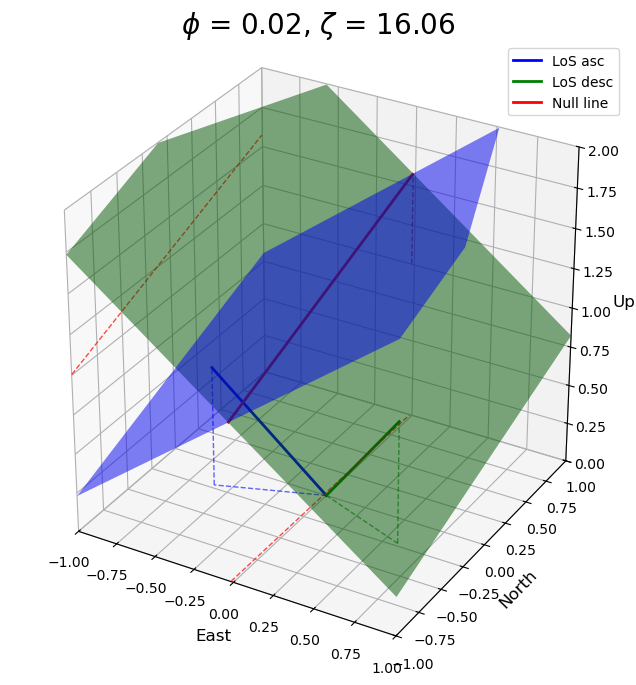

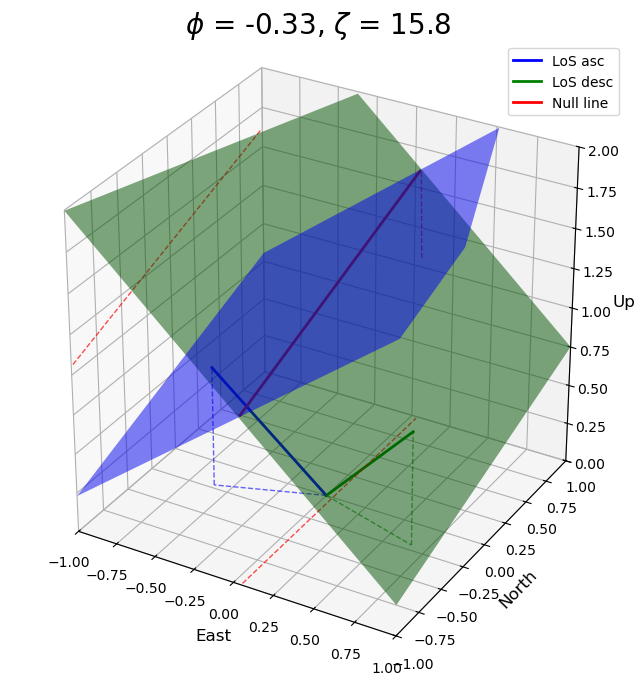

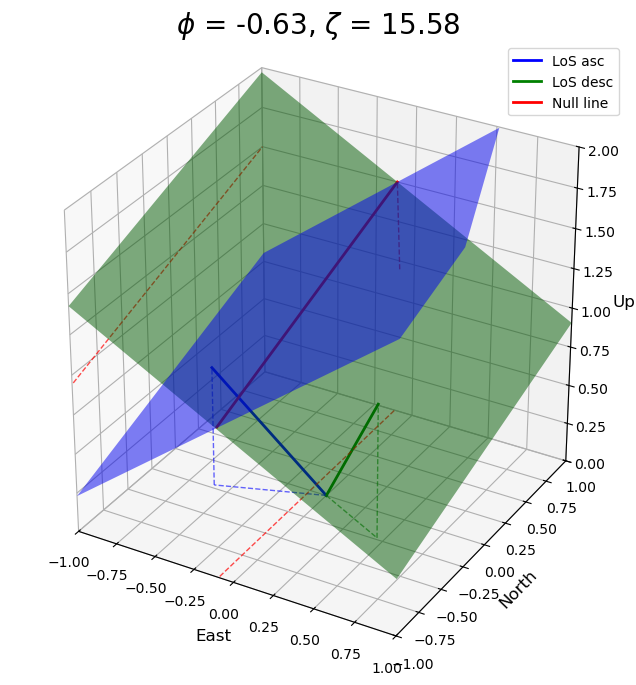

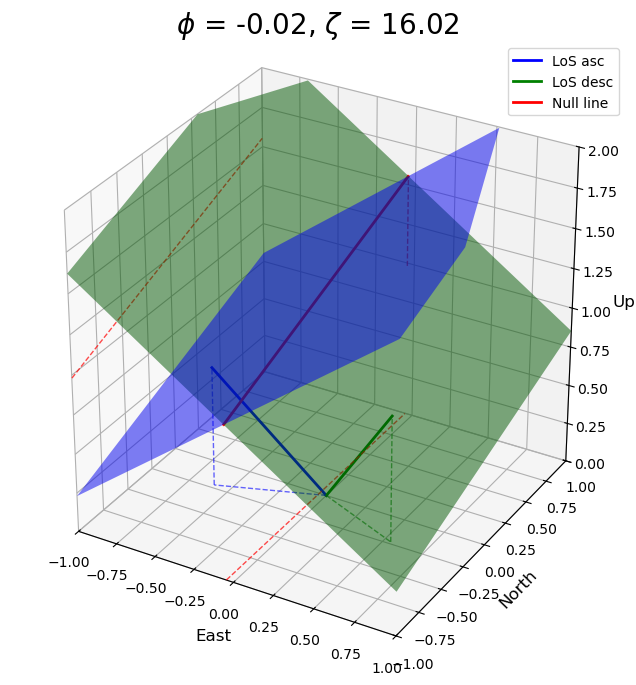

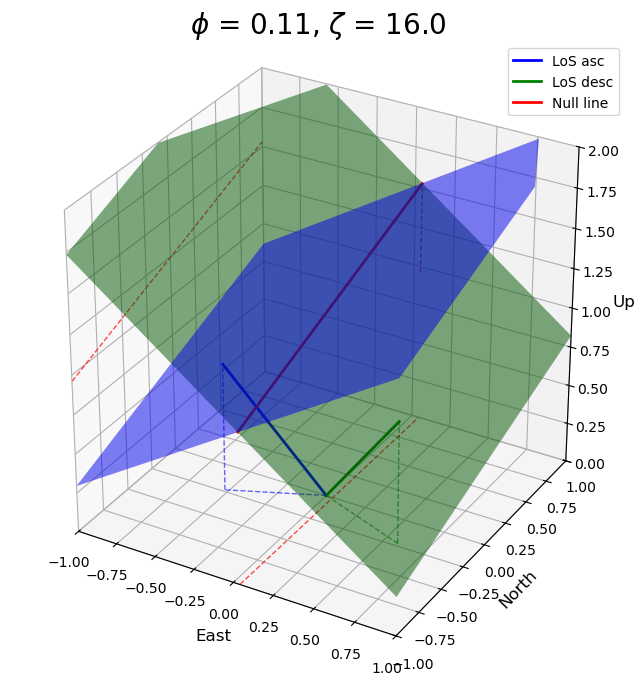

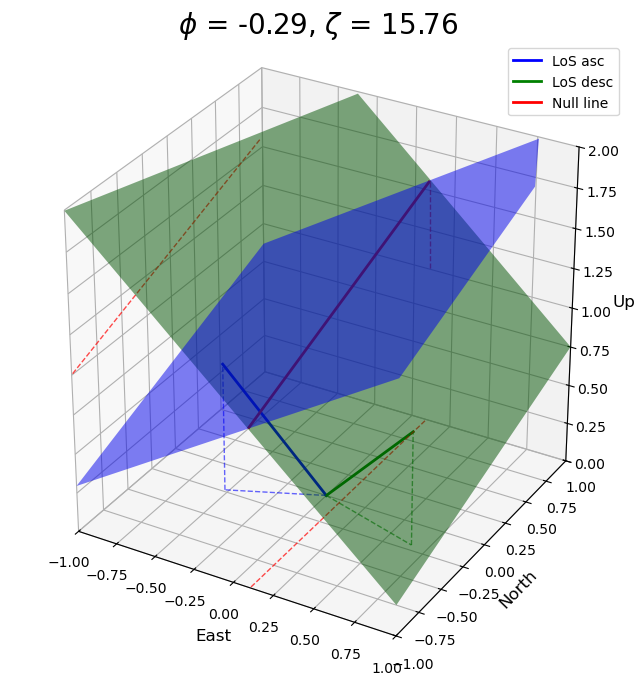

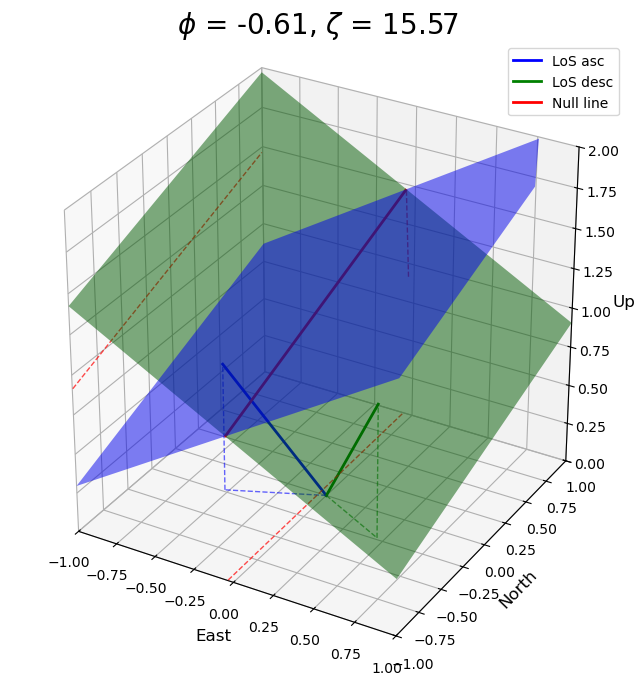

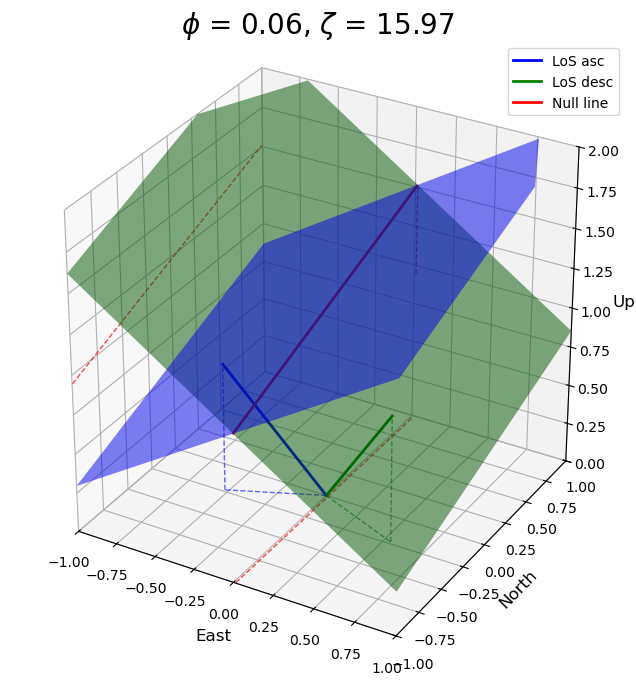

In [5]:
#Svalbard has a lot more observations, lets pick a couple of them

inc_a = asc_inc_svalbard[0][:4]   # picking the first 4 ascending observations
inc_d = desc_inc_svalbard[0][:4]  # picking the first 4 descending observations
alpha_asc = asc_alpha_svalbard[0][:4]
alpha_desc = desc_alpha_svalbard[0][:4]
phi = np.zeros((np.size(inc_a), np.size(inc_d)))
zeta = np.zeros((np.size(inc_a), np.size(inc_d)))

for i in range(np.size(inc_a)):
    for j in range(np.size(inc_d)):
        inc = np.array([inc_a[i], inc_d[j]])
        alpha_d = np.array([alpha_asc[i], alpha_desc[j]])
        
        unit_los_enu, zeta[i,j], phi[i,j], xi = nd.null_space_2sat(inc, alpha_d, 1, 'LoS asc', 'LoS desc')


# Estimate viewing geometry and values for phi and zeta for a grid of coordinates

We can also compute the viewing geometry for mulitple coordinates on a grid. Consequently, we can plot the incidence angle and azimuth of the ZDP for these locations. 

You can use the pickled data `viewing_geometry_for_a_grid_of_coordinates.pkl` that already has the computed viewing geometry needed.

As a last step, we can also plot geometry of the null line for all these locations. 


In [6]:


path = '/Users/isabelslingerland/No-DRaMA/viewing_geometry_for_a_grid_of_coordinates.pkl'

with open(path, 'rb') as f:
    results = pickle.load(f)

nr_asc_obs = results['nr_asc_obs']
nr_desc_obs = results['nr_desc_obs']
asc_inc = results['asc_inc']
desc_inc = results['desc_inc']
asc_alpha = results['asc_alpha']
desc_alpha = results['desc_alpha']
inc_max_a = results['inc_max_a']
inc_min_a = results['inc_min_a']
inc_alpha_max_a = results['inc_alpha_max_a']
inc_alpha_min_a = results['inc_alpha_min_a']
alpha_max_a = results['alpha_max_a']
alpha_min_a = results['alpha_min_a']
alpha_inc_max_a = results['alpha_inc_max_a']
alpha_inc_min_a = results['alpha_inc_min_a']
inc_max_d = results['inc_max_d']
inc_min_d = results['inc_min_d']
inc_alpha_max_d = results['inc_alpha_max_d']
inc_alpha_min_d = results['inc_alpha_min_d']
alpha_max_d = results['alpha_max_d']
alpha_min_d = results['alpha_min_d']
alpha_inc_max_d = results['alpha_inc_max_d']
alpha_inc_min_d = results['alpha_inc_min_d']

print("Results loaded for grid!")

Results loaded for grid!


In [7]:
min_lon = 30
max_lon = 50
min_lat = -76
max_lat = 85

# Define values for plotting 
lon_plot = np.linspace(min_lon, max_lon, 6)
lat_plot = np.linspace(max_lat, -75, 17)

lat_grid, lon_grid = np.mgrid[min_lat:max_lat:0.2, min_lon:max_lon:0.1]
lat = lat_grid[:, 0]
lon = lon_grid[0, :]


# Define values for plotting 
lon_plot = np.linspace(min_lon, max_lon, 6)
lat_plot = np.linspace(max_lat, -75, 17)


The next step is to estimate the orientation of the null line for all locations on earth. This is done with `phi_zeta_grid`. 

Text(0, 0.5, 'Latitude')

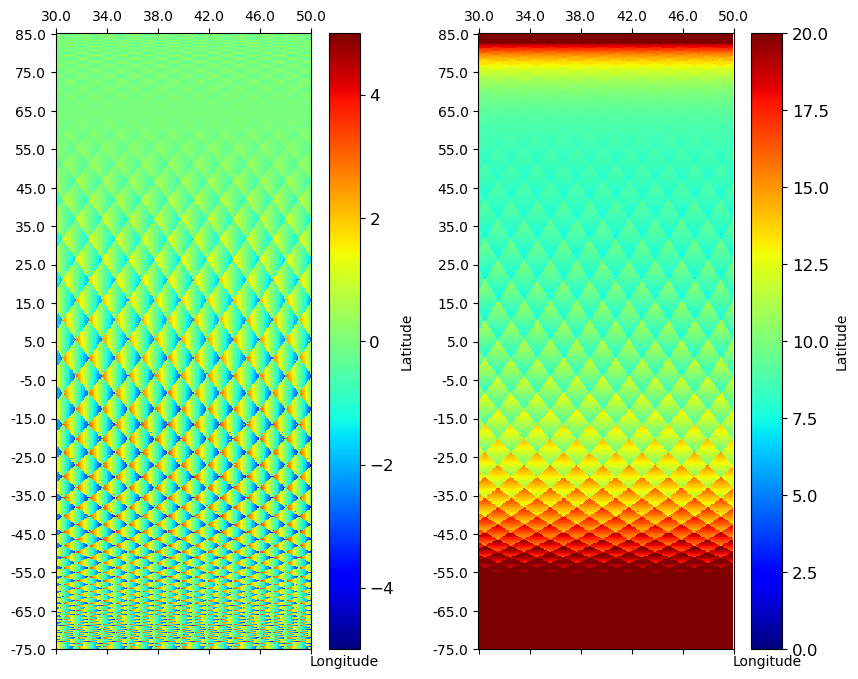

In [8]:
phi, zeta = nd.phi_zeta_grid(inc_max_a, inc_max_d, alpha_inc_max_a, alpha_inc_max_d)
fig = plt.figure(figsize = (10,8))
ax = fig.add_subplot(121)
phi_plot = ax.matshow((np.flipud(phi)), cmap='jet', vmin = -5, vmax = 5, aspect = 0.6)
cb = fig.colorbar(phi_plot)
cb.set_label(label = r'$\phi$ [degrees]', size=16)
cb.ax.tick_params(labelsize='large')
xaxis = np.linspace(0, len(lon), len(lon_plot))
yaxis = np.linspace(0, len(lat), len(lat_plot))
ax.set_xticks(xaxis)
ax.set_yticks(yaxis)
ax.set_xticklabels(lon_plot)
ax.set_yticklabels(lat_plot)
plt.xlabel('Longitude', fontsize = 10)
plt.ylabel('Latitude', fontsize=10)


ax = fig.add_subplot(122)
zeta_plot = ax.matshow((np.flipud(zeta)), cmap='jet', vmin = 0, vmax = 20, aspect = 0.6)
cb = fig.colorbar(zeta_plot)
cb.set_label(label = r'$\zeta$ [degrees]', size=16)
cb.ax.tick_params(labelsize='large')
xaxis = np.linspace(0, len(lon), len(lon_plot))
yaxis = np.linspace(0, len(lat), len(lat_plot))
ax.set_xticks(xaxis)
ax.set_yticks(yaxis)
ax.set_xticklabels(lon_plot)
ax.set_yticklabels(lat_plot)
plt.xlabel('Longitude', fontsize = 10)
plt.ylabel('Latitude', fontsize=10)



In [9]:
# Print the values for the null line for different latitudinal coordinates on Earth

lat_value = np.array([51.0, 41.0, 34.0, 1.0, -34.0, 65.0])
lon_value = 40.0

ravel_lat = np.ravel(lat_grid)
ravel_lon = np.ravel(lon_grid)

ravel_phi = np.ravel(phi)
ravel_zeta = np.ravel(zeta)

for i in range(len(lat_value)):
    
    index_pnt = (np.where((ravel_lat == lat_value[i]) * (ravel_lon == lon_value)))[0]
    index_pnt[0]

    print ('Phi at lat', lat_value[i])
    print (ravel_phi[index_pnt])
    
    print ('Zeta at lat', lat_value[i])
    print (ravel_zeta[index_pnt])

Phi at lat 51.0
[-0.13340772]
Zeta at lat 51.0
[8.48810346]
Phi at lat 41.0
[-0.2524471]
Zeta at lat 41.0
[8.38825191]
Phi at lat 34.0
[-0.30683254]
Zeta at lat 34.0
[9.18399566]
Phi at lat 1.0
[-0.71917351]
Zeta at lat 1.0
[10.17997629]
Phi at lat -34.0
[2.67458722]
Zeta at lat -34.0
[13.35904507]
Phi at lat 65.0
[-0.01025981]
Zeta at lat 65.0
[9.30581402]


## Estimate the relation between the incidence angle, $\theta$, and the azimuth of the ZDP, $\alpha_d$

For locations with multiple available viewing geometries we can estimate the relation between the incidence angle and the azimuth angle of the zero-doppler plane.


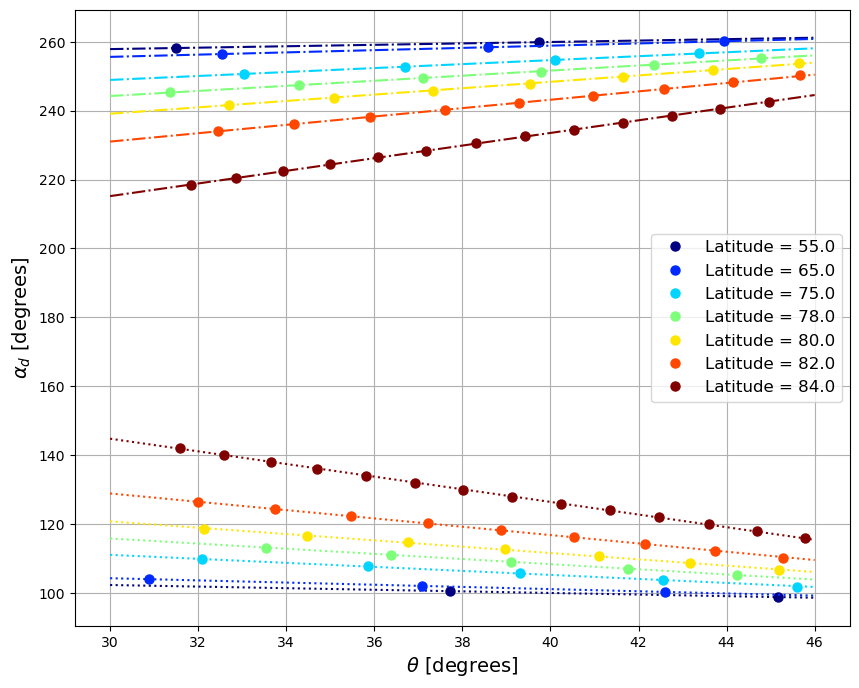

In [10]:
lat_value = np.array([55.0, 65.0, 75.0, 78, 80, 82, 84.0])
lon_value = 40.0

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.jet(np.linspace(0, 1, len(lat_value)))

ravel_lat = np.ravel(lat_grid)
ravel_lon = np.ravel(lon_grid)

for i in range(len(lat_value)):
    
    index_pnt = (np.where((ravel_lat == lat_value[i]) * (ravel_lon == lon_value)))[0]

    inc_a = asc_inc[index_pnt[0]]
    azimuth_a = asc_alpha[index_pnt[0]]
    inc_d = desc_inc[index_pnt[0]]
    azimuth_d = desc_alpha[index_pnt[0]]
    
    inc_a = inc_a[~np.isnan(inc_a)]
    inc_d = inc_d[~np.isnan(inc_d)]
    azimuth_a = azimuth_a[~np.isnan(azimuth_a)]
    azimuth_d = azimuth_d[~np.isnan(azimuth_d)]
    
    poly_a = np.polyfit(np.rad2deg(inc_a), np.rad2deg(azimuth_a), 1)
    poly_d = np.polyfit(np.rad2deg(inc_d), np.rad2deg(azimuth_d), 1)
    
    inc_fit = np.linspace(30, 46, 20)
    c = colors[i]
    
    ax.plot(np.rad2deg(inc_d), np.rad2deg(azimuth_d), '.', color=c, label='Latitude = ' + str(lat_value[i]), markersize=13)
    ax.plot(inc_fit, poly_d[0] * inc_fit + poly_d[1], linestyle='dotted', color=c)
    ax.plot(np.rad2deg(inc_a), np.rad2deg(azimuth_a), '.', color=c, markersize=13)
    ax.plot(inc_fit, poly_a[0] * inc_fit + poly_a[1], linestyle='dashdot', color=c)

ax.set_ylabel(r'$\alpha_d$ [degrees]', fontsize=14)
ax.set_xlabel(r'$\theta$ [degrees]', fontsize=14)
ax.grid()
ax.legend(fontsize=12)
plt.show()